# 1. Data Preparation
This [dataset](https://www.kaggle.com/datasets/rabieelkharoua/air-quality-and-health-impact-dataset) contains comprehensive information on the air quality and its impact on public health for 5,811 records. It includes variables such as air quality index (AQI), concentrations of various pollutants, weather conditions, and health impact metrics. The target variable is the health impact class, which categorizes the health impact based on the air quality and other related factors.

This dataset offers a comprehensive view of the relationship between air quality and public health, making it ideal for research, predictive modeling, and statistical analysis.

In [1]:
include("utils.jl")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
┌ Info: Running `conda install -y -c anaconda conda` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - anaconda
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - conda


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::certifi-2024.8.30~ --> anaconda/linux-64::certifi-2024.8.30-py312h06a4308_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


┌ Info: Running `conda install -y -c conda-forge 'libstdcxx-ng>=3.4,<13.0'` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - conda-forge
 - bioconda
 - defaults
 - anaconda
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - libstdcxx-ng[version='>=3.4,<13.0']


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            anaconda/linux-64::certifi-2024.8.30-~ --> conda-forge/noarch::certifi-2024.8.30-pyhd8ed1ab_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


print_confusion_matrix (generic function with 2 methods)

In [2]:
using CSV, DataFrames

# Load the dataset from the 'dataset' folder
data = CSV.read("datasets/air_quality_health_impact_data.csv", DataFrame)

# Check the dataset
describe(data)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,RecordID,2906.0,1,2906.0,5811,0,Int64
2,AQI,248.438,0.00581738,249.128,499.859,0,Float64
3,PM10,148.655,0.0158481,147.635,299.902,0,Float64
4,PM2_5,100.224,0.0315489,100.506,199.985,0,Float64
5,NO2,102.293,0.00962478,102.988,199.98,0,Float64
6,SO2,49.4568,0.0110232,49.5302,99.9696,0,Float64
7,O3,149.312,0.001661,149.56,299.937,0,Float64
8,Temperature,14.9755,-9.991,14.9424,39.9634,0,Float64
9,Humidity,54.7769,10.0015,54.5439,99.9975,0,Float64


In [3]:
input_data = Matrix(data[!, 1:13]);
output_data = Int.(data[!, 15]);

@assert input_data isa Matrix
@assert output_data isa Vector{Int64}

To split the test from train we use the holdOut function with a fraction of 0.2. This means that 20% of the train data will be used for testing and the remaining 80% will be used for training.

In [4]:
# Split in train and test
(tr_idx, test_idx) = holdOut(size(input_data, 1), 0.2)

train_input = input_data[tr_idx,:]
train_output = output_data[tr_idx]
test_input = input_data[test_idx,:]
test_output = output_data[test_idx]

train_output = collect(train_output)
test_output = collect(test_output)

println("Train Input Size: ", size(train_input))
println("Train Output Size: ", size(train_output), " Categories:", sort(unique(train_output)))
println("Test Input Size: ", size(test_input))
println("Test Output Size: ", size(test_output), " Categories:", sort(unique(test_output)))


Train Input Size: (4649, 13)
Train Output Size: (4649,) Categories:[0, 1, 2, 3, 4]
Test Input Size: (1162, 13)
Test Output Size: (1162,) Categories:[0, 1, 2, 3, 4]


We will store the results in a DataFrame for easy ploting

In [5]:
metric_names = [:approach, :accuracy, :error_rate, :recall, :specificity, :ppv, :npv, :f_score]
metric_types = [String[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[]]
metrics = DataFrame(metric_types, metric_names)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


# 2. Definition of Models and Hyperparameters

In [6]:
## These are the modelsHyperParameters to be used in the models training

modelsHyperParameters = [
    # ANN configurations
    Dict("estimator" => :ANN, "topology" => (64,), "maxEpochs" => 200, "learningRate" => 0.01),
    Dict("estimator" => :ANN, "topology" => (128,), "maxEpochs" => 150, "learningRate" => 0.005),
    Dict("estimator" => :ANN, "topology" => (64, 32), "maxEpochs" => 100, "learningRate" => 0.01),
    Dict("estimator" => :ANN, "topology" => (128, 64), "maxEpochs" => 200, "learningRate" => 0.001),
    Dict("estimator" => :ANN, "topology" => (256,), "maxEpochs" => 300, "learningRate" => 0.0005),
    Dict("estimator" => :ANN, "topology" => (128, 64, 32), "maxEpochs" => 200, "learningRate" => 0.01),
    Dict("estimator" => :ANN, "topology" => (64, 64), "maxEpochs" => 250, "learningRate" => 0.005),
    Dict("estimator" => :ANN, "topology" => (256, 128), "maxEpochs" => 200, "learningRate" => 0.001),

    # SVM configurations
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 1.0, "degree"=>2),
    Dict("estimator" => :SVM, "kernel" => "linear", "C" => 1.0, "degree"=>4),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 0.01 , "degree" => 2),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 1.0, "degree" => 3),
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.01, "degree" => 3),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 5, "degree" => 3),
    Dict("estimator" => :SVM, "kernel" => "linear", "C"=> 0.1, "degree" => 3),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 10.0, "degree" => 5),

    # Decision Tree configurations
    Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 7, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 10, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 15, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 20, "random_state" => 42),

    # kNN configurations
    Dict("estimator" => :KNN, "k" => 3),
    Dict("estimator" => :KNN, "k" => 5),
    Dict("estimator" => :KNN, "k" => 7),
    Dict("estimator" => :KNN, "k" => 9),
    Dict("estimator" => :KNN, "k" => 11),
    Dict("estimator" => :KNN, "k" => 15)
]

# println(modelsHyperParameters)

28-element Vector{Dict{String, Any}}:
 Dict("maxEpochs" => 200, "learningRate" => 0.01, "estimator" => :ANN, "topology" => (64,))
 Dict("maxEpochs" => 150, "learningRate" => 0.005, "estimator" => :ANN, "topology" => (128,))
 Dict("maxEpochs" => 100, "learningRate" => 0.01, "estimator" => :ANN, "topology" => (64, 32))
 Dict("maxEpochs" => 200, "learningRate" => 0.001, "estimator" => :ANN, "topology" => (128, 64))
 Dict("maxEpochs" => 300, "learningRate" => 0.0005, "estimator" => :ANN, "topology" => (256,))
 Dict("maxEpochs" => 200, "learningRate" => 0.01, "estimator" => :ANN, "topology" => (128, 64, 32))
 Dict("maxEpochs" => 250, "learningRate" => 0.005, "estimator" => :ANN, "topology" => (64, 64))
 Dict("maxEpochs" => 200, "learningRate" => 0.001, "estimator" => :ANN, "topology" => (256, 128))
 Dict("estimator" => :SVM, "C" => 1.0, "kernel" => "rbf", "degree" => 2)
 Dict("estimator" => :SVM, "C" => 1.0, "kernel" => "linear", "degree" => 4)
 ⋮
 Dict("estimator" => :DecisionTree, "max_de

----
----

# 3. First approach: Using Min-Max Normalization.

In this approach we will use the Min-Max Normalization technique to normalize the data. And then, realize all the models training to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [7]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.4348424857978998 0.9580091865828126 … 0.07142857142857142 0.25; 0.8297469443966259 0.2891297634490026 … 0.35714285714285715 0.25; … ; 0.9363057324840764 0.4605928084658687 … 0.5 0.08333333333333333; 0.20795317610604236 0.9977094048196059 … 0.5 0.16666666666666666], [0.2399724565329661 0.8293676174773519 … 0.2857142857142857 0.16666666666666666; 0.7705284902737132 0.35801367417266006 … 0.2857142857142857 0.08333333333333333; … ; 0.2244792563263901 0.8714785538480382 … 0.5 0.08333333333333333; 0.06386641418488552 0.09448782111775324 … 0.5 0.25])

In this approach we wont use crossValidation, so we will train the models on the whole dataset and then evaluate them on the test set.

Pre-normalization data characteristics:

In [8]:
describe(DataFrame(train_input, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,2905.96,2.0,2920.0,5811.0,0,Float64
2,AQI,248.448,0.00581738,250.758,499.707,0,Float64
3,PM10,148.0,0.0158481,146.105,299.902,0,Float64
4,PM2_5,100.066,0.0315489,100.808,199.985,0,Float64
5,NO2,102.222,0.00962478,103.075,199.98,0,Float64
6,SO2,49.5396,0.0110232,49.6864,99.9598,0,Float64
7,O3,149.742,0.001661,150.739,299.92,0,Float64
8,Temperature,14.8654,-9.991,14.727,39.9634,0,Float64
9,Humidity,54.829,10.0015,54.6134,99.9975,0,Float64


Post-normalization data with min-max:

In [9]:
describe(DataFrame(train_input_minmax, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.499908,0.0,0.502324,1.0,0,Float64
2,AQI,0.497182,0.0,0.501805,1.0,0,Float64
3,PM10,0.493466,0.0,0.487148,1.0,0,Float64
4,PM2_5,0.500291,0.0,0.503998,1.0,0,Float64
5,NO2,0.511139,0.0,0.515402,1.0,0,Float64
6,SO2,0.49554,0.0,0.497008,1.0,0,Float64
7,O3,0.499271,0.0,0.502596,1.0,0,Float64
8,Temperature,0.497581,0.0,0.49481,1.0,0,Float64
9,Humidity,0.498105,0.0,0.49571,1.0,0,Float64


In [10]:
accuracies_minmax = []
models_minmax = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_minmax, train_output)
    acc = score(model, test_input_minmax, test_output)
    push!(accuracies_minmax, (idx, modelHyperParameters["estimator"], acc))
    push!(models_minmax, deepcopy(model))
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Once we have the accuracies, we will take the best of each model to create the ensemble, in this case we will create a stack, and then train the stack.

In [11]:
#println(accuracies_minmax)
best_models_minmax = best_model_positions(accuracies_minmax)

stacking_classifier_minmax = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models_minmax[idx]) for idx in best_models_minmax],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier_minmax, train_input_minmax, train_output)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

PyObject StackingClassifier(estimators=[('m25_KNN', KNeighborsClassifier(n_neighbors=7)),
                               ('m9_SVM', SVC(degree=2)),
                               ('m4_ANN',
                                MLPClassifier(hidden_layer_sizes=(128, 64))),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=10,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

Now we get the metrics of the stack ensemble.
After the best model selection and the stacking process, in some cases, we miss one of the clases in the output, so we decided to add 1 element of each class both in the train and in the test outputs.

In [12]:
outputs_minmax = stacking_classifier_minmax.predict(test_input_minmax)

x = copy(outputs_minmax)
y = vec(copy(test_output))

# We need to ensure that the confusion matrix recives the same categories:
if size(unique(x),1) != size(unique(y),1)
    append!(x, unique(output_data))
    append!(y, unique(output_data))
end

accuracy, error_rate, recall, specificity, ppv, npv, f_score, cm = confusionMatrix(x, y)
push!(metrics, ["MinMax", accuracy, error_rate, recall, specificity, ppv, npv, f_score])


Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.96401,0.0359897,0.962663,0.0373371,0.900065,0.964451,0.910026


And print the metrics for this First Approach:

In [13]:
# Display results
println("CONFUSION MATRIX 1st APPROACH (Min-Max Normalization):")
print_confusion_matrix(cm, ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"])

CONFUSION MATRIX 1st APPROACH (Min-Max Normalization):
CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       948        15         4         9         9
   Class 1         7       110         7         1         5
   Class 2         0         1         2        42         0
   Class 3         0         0         5         1         0
   Class 4         0         0         0         0         1


## In this point we should make the analisys of the results

----
----

# 4. Second Approach: Using Standard normalization

In this approach we will use the Zero-Mean Normalization technique to normalize the data. And then, train the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [14]:
train_input_zm, test_input_zm = normalizeData(train_input, test_input, :MinMax)

([0.4348424857978998 0.9580091865828126 … 0.07142857142857142 0.25; 0.8297469443966259 0.2891297634490026 … 0.35714285714285715 0.25; … ; 0.9363057324840764 0.4605928084658687 … 0.5 0.08333333333333333; 0.20795317610604236 0.9977094048196059 … 0.5 0.16666666666666666], [0.2399724565329661 0.8293676174773519 … 0.2857142857142857 0.16666666666666666; 0.7705284902737132 0.35801367417266006 … 0.2857142857142857 0.08333333333333333; … ; 0.2244792563263901 0.8714785538480382 … 0.5 0.08333333333333333; 0.06386641418488552 0.09448782111775324 … 0.5 0.25])

Post-normalization data with zero-mean:

In [15]:
describe(DataFrame(train_input_zm, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.499908,0.0,0.502324,1.0,0,Float64
2,AQI,0.497182,0.0,0.501805,1.0,0,Float64
3,PM10,0.493466,0.0,0.487148,1.0,0,Float64
4,PM2_5,0.500291,0.0,0.503998,1.0,0,Float64
5,NO2,0.511139,0.0,0.515402,1.0,0,Float64
6,SO2,0.49554,0.0,0.497008,1.0,0,Float64
7,O3,0.499271,0.0,0.502596,1.0,0,Float64
8,Temperature,0.497581,0.0,0.49481,1.0,0,Float64
9,Humidity,0.498105,0.0,0.49571,1.0,0,Float64


In [16]:
accuracies_zm = []
models_zm = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_zm, train_output)
    acc = score(model, test_input_zm, test_output)
    push!(accuracies_zm, (idx, modelHyperParameters["estimator"], acc))
    push!(models_zm, deepcopy(model))
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

In [17]:
best_models_zm = best_model_positions(accuracies_zm)

stacking_classifier_zm = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models_zm[idx]) for idx in best_models_zm],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier_zm, train_input_zm, train_output)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

PyObject StackingClassifier(estimators=[('m25_KNN', KNeighborsClassifier(n_neighbors=7)),
                               ('m9_SVM', SVC(degree=2)),
                               ('m4_ANN',
                                MLPClassifier(hidden_layer_sizes=(128, 64))),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=10,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

In [18]:
outputs_zm = stacking_classifier_zm.predict(test_input_zm)

x = copy(outputs_zm)
y = vec(copy(test_output))

# We need to ensure that the confusion matrix recives the same categories:
if size(unique(x),1) != size(unique(y),1)
    append!(x, unique(output_data))
    append!(y, unique(output_data))
end

accuracy, error_rate, recall, specificity, ppv, npv, f_score, cm = confusionMatrix(x, y)
push!(metrics, ["ZeroMean", accuracy, error_rate, recall, specificity, ppv, npv, f_score])

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.96401,0.0359897,0.962663,0.0373371,0.900065,0.964451,0.910026
2,ZeroMean,0.963668,0.0363325,0.961102,0.0388982,0.898113,0.955997,0.909169


In [19]:
println("CONFUSION MATRIX 2nd APPROACH (Zero-Mean Normalization):")
print_confusion_matrix(cm, ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"])

CONFUSION MATRIX 2nd APPROACH (Zero-Mean Normalization):
CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       946        13         8         7         9
   Class 1         9       111         3         7         4
   Class 2         0         2         2        38         1
   Class 3         0         0         5         1         0
   Class 4         0         0         0         0         1


----
----

# Some Ploting

In [20]:
df = copy(metrics)
df

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.96401,0.0359897,0.962663,0.0373371,0.900065,0.964451,0.910026
2,ZeroMean,0.963668,0.0363325,0.961102,0.0388982,0.898113,0.955997,0.909169


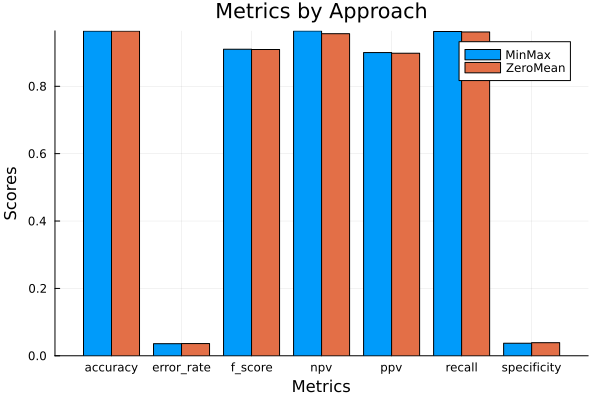

In [21]:
using StatsPlots

ctg = repeat(["MinMax", "ZeroMean"], inner=7)
nam = repeat(names(df)[2:8], outer=2)
mm = collect(df[1,2:8])
zm = collect(df[2,2:8])

groupedbar(nam, [mm zm], group = ctg, xlabel = "Metrics", ylabel = "Scores",
           title = "Metrics by Approach")


----
----

# 5. Third Approach: Using Crossvalidation

In this approach we will use the Crossvalidation technique to to train the models, and using the normalization of the data that gave us the best results in the previous steps.